# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Load Dataset

In [ ]:
import numpy as np
import pandas as pd
# # Dataset path
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/MIT-BIH Arrhythmia Database.csv"



# Read Data

In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sahu/MIT-BIH Arrhythmia Database.csv")

data

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,101,N,76,313.0,0.074347,-0.160548,1.036401,-0.285662,-0.026824,41,...,0.025930,2,18,22,2,0.025930,0.025930,0.025930,0.025436,0.025436
1,101,N,313,315.0,-0.052079,-0.264784,0.886597,-0.366298,-0.059710,21,...,-0.042009,26,27,62,9,-0.042009,-0.029498,0.005012,0.030892,0.002986
2,101,N,315,321.0,-0.062151,-0.296983,0.991859,-0.410306,-0.065686,22,...,0.009528,3,8,12,1,0.009528,0.009528,0.008786,0.008786,0.008368
3,101,N,321,336.0,-0.063322,-0.281386,1.034903,-0.403880,-0.071750,22,...,-0.020536,6,9,16,1,-0.020536,-0.020257,-0.018965,-0.016968,-0.014555
4,101,N,336,344.0,-0.062915,1.046914,1.046408,1.046408,-0.074639,11,...,0.016053,16,5,31,10,0.016053,0.006742,0.002782,-0.007798,-0.051155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100684,234,N,240,241.0,-0.110230,1.420339,1.403346,1.403346,-0.115682,14,...,-0.069234,5,6,20,9,-0.069234,-0.068378,-0.065373,-0.060779,-0.054383
100685,234,N,241,243.0,-0.119014,1.424782,1.420328,1.420328,-0.134406,13,...,-0.069530,7,5,20,8,-0.069530,-0.069290,-0.066317,-0.053437,-0.045120
100686,234,N,243,252.0,0.173524,-0.443214,1.436878,-0.714642,-0.136431,38,...,-0.089396,9,7,24,8,-0.089396,-0.088155,-0.078611,-0.066763,-0.058650
100687,234,N,252,244.0,-0.119820,-0.401522,1.337051,-0.688560,-0.125076,27,...,-0.065487,3,1,12,8,-0.065487,-0.065487,-0.064941,-0.064941,-0.061120


# Data Balancing

# Smote

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

X = data.drop('type', axis=1)
y = data['type']

# Current distribution
print("Original distribution:")
print(y.value_counts())

# Classes >100 reduce
under_strategy = {cls:750 for cls, count in y.value_counts().items() if count > 750}

# Classes <100 increase
over_strategy = {cls:750 for cls, count in y.value_counts().items() if count < 750}

# 1️ Under sampling
if under_strategy:
    rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
    X, y = rus.fit_resample(X, y)

# 2️ Over sampling
if over_strategy:
    smote = SMOTE(sampling_strategy=over_strategy, random_state=42)
    X, y = smote.fit_resample(X, y)

# Final dataframe
data_balanced = pd.concat(
    [pd.DataFrame(X), pd.DataFrame(y, columns=['type'])],
    axis=1
)

print("\nBalanced distribution:")
print(data_balanced['type'].value_counts())

Original distribution:
type
N       90083
VEB      7009
SVEB     2779
F         803
Q          15
Name: count, dtype: int64

Balanced distribution:
type
F       750
N       750
Q       750
SVEB    750
VEB     750
Name: count, dtype: int64


# **Preprocessing**

# ECG Noise Elimination (Bandpass Filter 5–15 Hz)

Saved to: /content/drive/MyDrive/Colab Notebooks/Sahu/Preprocessed_ECG.csv


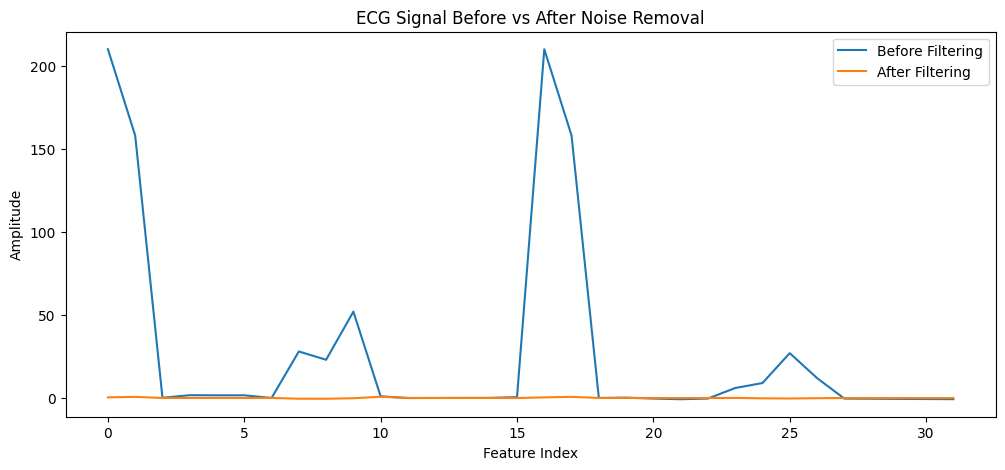

,record,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,0_pq_interval,...,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,type
0,208,0.367071,0.688869,0.003299,0.015049,0.023417,-0.011122,0.009083,-0.437604,-0.462726,...,0.024087,-0.203125,-0.310775,-0.131736,-0.020393,-0.024445,-0.031063,-0.033938,-0.036959,F
1,208,0.942098,6.858219,-0.016818,-0.164585,0.041406,-0.349092,-0.004145,0.549593,-2.020612,...,0.095795,0.308755,0.459652,0.055102,-0.132964,-0.130865,-0.139109,-0.133915,-0.132014,F
2,208,1.460215,12.885004,-0.035672,-0.335915,0.055860,-0.669869,-0.016481,1.452680,-3.513604,...,0.162653,0.815547,1.207181,0.228982,-0.238756,-0.230738,-0.240311,-0.227281,-0.220483,F
3,213,1.927727,18.553501,-0.052289,-0.492809,0.065702,-0.961858,-0.027135,2.223957,-4.892208,...,0.226290,1.297374,1.899852,0.376188,-0.332815,-0.319402,-0.329890,-0.309569,-0.298025,F
4,213,2.347714,23.664134,-0.065836,-0.629964,0.070178,-1.214959,-0.035439,2.823073,-6.112951,...,0.287370,1.736408,2.509486,0.485707,-0.411002,-0.392966,-0.403873,-0.377094,-0.361086,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,4.651381,-13.803897,-0.462216,0.016525,-0.076077,-0.062806,-0.009093,-20.177309,-15.873473,...,0.318263,-0.985736,-1.255574,-0.591892,0.034301,0.045929,0.054503,0.038628,0.024496,Q
3746,174,5.189267,-11.738323,-0.365970,0.033834,-0.061229,-0.040064,-0.011129,-16.409498,-12.725894,...,0.293539,-0.902771,-1.228073,-0.613422,0.034581,0.043785,0.049621,0.034077,0.019888,Q
3747,104,5.445730,-9.248142,-0.261433,0.046632,-0.046194,-0.016760,-0.013759,-12.160455,-9.230897,...,0.254141,-0.778301,-1.143750,-0.606698,0.032602,0.039148,0.042273,0.027919,0.014532,Q
3748,185,5.431388,-6.493172,-0.153954,0.054946,-0.031676,0.006043,-0.016910,-7.662781,-5.574799,...,0.203537,-0.621786,-1.013078,-0.576388,0.028671,0.032472,0.033040,0.020595,0.008741,Q


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
# import os
data=data_balanced


# Keep record and type unchanged
meta_cols = ['record','type']

# ECG signal columns
signal_cols = [col for col in data.columns if col not in meta_cols]

# -----------------------------
# Bandpass Filter (5–15 Hz)
# -----------------------------

fs = 360   # MIT-BIH sampling frequency
low = 5
high = 15

b, a = butter(3, [low/(fs/2), high/(fs/2)], btype='band')

filtered_data = data.copy()

for col in signal_cols:
    filtered_data[col] = filtfilt(b, a, data[col])

# -----------------------------
# Save Output
# -----------------------------

save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Preprocessed_ECG.csv"
filtered_data.to_csv(save_path, index=False)

print("Saved to:", save_path)

# -----------------------------
# Visualization
# -----------------------------

sample_index = 0

plt.figure(figsize=(12,5))

plt.plot(data[signal_cols].iloc[sample_index].values,
         label="Before Filtering")

plt.plot(filtered_data[signal_cols].iloc[sample_index].values,
         label="After Filtering")

plt.title("ECG Signal Before vs After Noise Removal")
plt.xlabel("Feature Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
filtered_data

# ECG Beat Segmentation

Beat Segmentation saved to: /content/drive/MyDrive/Colab Notebooks/Sahu/Beat_Segmented_ECG.csv


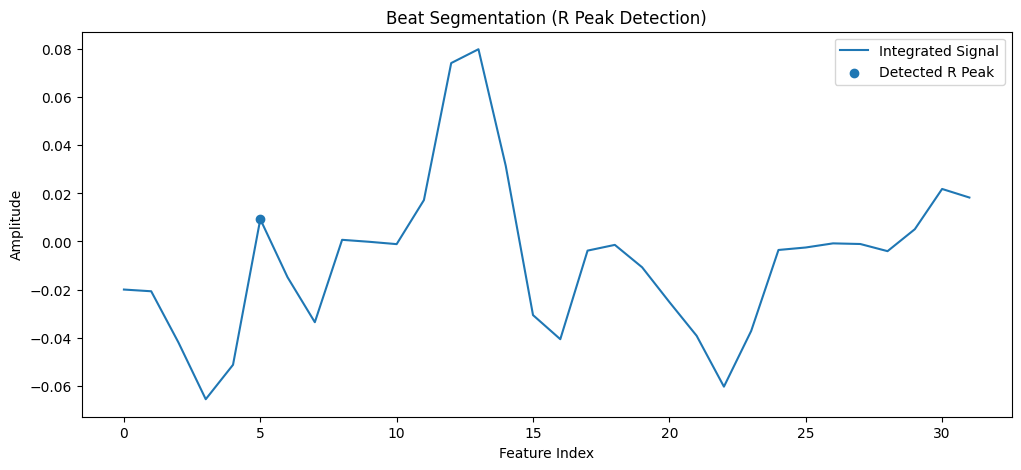

,record,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,0_pq_interval,...,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4,type,R_peak_index
0,208,0.367071,0.688869,0.003299,0.015049,0.023417,-0.011122,0.009083,-0.437604,-0.462726,...,-0.203125,-0.310775,-0.131736,-0.020393,-0.024445,-0.031063,-0.033938,-0.036959,F,5
1,208,0.942098,6.858219,-0.016818,-0.164585,0.041406,-0.349092,-0.004145,0.549593,-2.020612,...,0.308755,0.459652,0.055102,-0.132964,-0.130865,-0.139109,-0.133915,-0.132014,F,0
2,208,1.460215,12.885004,-0.035672,-0.335915,0.055860,-0.669869,-0.016481,1.452680,-3.513604,...,0.815547,1.207181,0.228982,-0.238756,-0.230738,-0.240311,-0.227281,-0.220483,F,0
3,213,1.927727,18.553501,-0.052289,-0.492809,0.065702,-0.961858,-0.027135,2.223957,-4.892208,...,1.297374,1.899852,0.376188,-0.332815,-0.319402,-0.329890,-0.309569,-0.298025,F,0
4,213,2.347714,23.664134,-0.065836,-0.629964,0.070178,-1.214959,-0.035439,2.823073,-6.112951,...,1.736408,2.509486,0.485707,-0.411002,-0.392966,-0.403873,-0.377094,-0.361086,F,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,4.651381,-13.803897,-0.462216,0.016525,-0.076077,-0.062806,-0.009093,-20.177309,-15.873473,...,-0.985736,-1.255574,-0.591892,0.034301,0.045929,0.054503,0.038628,0.024496,Q,6
3746,174,5.189267,-11.738323,-0.365970,0.033834,-0.061229,-0.040064,-0.011129,-16.409498,-12.725894,...,-0.902771,-1.228073,-0.613422,0.034581,0.043785,0.049621,0.034077,0.019888,Q,6
3747,104,5.445730,-9.248142,-0.261433,0.046632,-0.046194,-0.016760,-0.013759,-12.160455,-9.230897,...,-0.778301,-1.143750,-0.606698,0.032602,0.039148,0.042273,0.027919,0.014532,Q,6
3748,185,5.431388,-6.493172,-0.153954,0.054946,-0.031676,0.006043,-0.016910,-7.662781,-5.574799,...,-0.621786,-1.013078,-0.576388,0.028671,0.032472,0.033040,0.020595,0.008741,Q,6


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load preprocessed ECG
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Preprocessed_ECG.csv"
data = pd.read_csv(path)

# Keep meta columns unchanged
meta_cols = ['record', 'type']

# Signal columns
signal_cols = [col for col in data.columns if col not in meta_cols]

signals = data[signal_cols].values

# -----------------------------
# Gradient Calculation (Eq 5)
# -----------------------------
gradient = np.gradient(signals, axis=1)

# -----------------------------
# Moving Window Integration
# -----------------------------
window = 10

integrated = []

for row in gradient:
    integrated_signal = np.convolve(row, np.ones(window)/window, mode='same')
    integrated.append(integrated_signal)

integrated = np.array(integrated)

# -----------------------------
# R Peak Detection
# -----------------------------
r_peaks_list = []

for row in integrated:
    threshold = np.mean(row)
    peaks = np.where(row > threshold)[0]
    r_peaks_list.append(peaks[0] if len(peaks) > 0 else -1)

# Add R peak column without disturbing type
segmented_data = data.copy()
segmented_data['R_peak_index'] = r_peaks_list

# -----------------------------
# Save Segmented Data
# -----------------------------

save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Beat_Segmented_ECG.csv"
segmented_data.to_csv(save_path, index=False)

print("Beat Segmentation saved to:", save_path)

# -----------------------------
# Visualization
# -----------------------------

sample = 0

plt.figure(figsize=(12,5))

plt.plot(integrated[sample], label="Integrated Signal")

r_peak = r_peaks_list[sample]

if r_peak != -1:
    plt.scatter(r_peak, integrated[sample][r_peak],
                label="Detected R Peak")

plt.title("Beat Segmentation (R Peak Detection)")
plt.xlabel("Feature Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()
segmented_data

# **Feacture Extraction**

# Multi-Feature Extraction

# Fractional Discrete Cosine Transform

In [ ]:
import pandas as pd
import numpy as np
from scipy.fftpack import dct

# Load segmented dataset
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Beat_Segmented_ECG.csv"
data = pd.read_csv(path)

# Preserve these columns
meta_cols = ['record','type','R_peak_index']

# Signal columns only
signal_cols = [col for col in data.columns if col not in meta_cols]

signals = data[signal_cols].values

# FDCT extraction
fdct_features = []

for row in signals:

    coeff = dct(row, norm='ortho')

    fdct_features.append(coeff[:10])

fdct_features = np.array(fdct_features)

fdct_df = pd.DataFrame(
    fdct_features,
    columns=[f'FDCT_{i}' for i in range(10)]
)

# Merge meta columns + features
fdct_output = pd.concat([data[meta_cols], fdct_df], axis=1)

# Save
save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/FDCT_Features.csv"

fdct_output.to_csv(save_path,index=False)

print("Saved:",save_path)
fdct_output

Saved: /content/drive/MyDrive/Colab Notebooks/Sahu/FDCT_Features.csv


,record,type,R_peak_index,FDCT_0,FDCT_1,FDCT_2,FDCT_3,FDCT_4,FDCT_5,FDCT_6,FDCT_7,FDCT_8,FDCT_9
0,208,F,5,0.185947,0.328147,-0.145839,0.292854,0.732273,0.190819,0.240763,0.248389,-0.064003,-0.295985
1,208,F,0,4.252146,2.751503,-1.146482,0.493414,1.821574,1.400746,1.979630,4.227817,1.476894,-3.370781
2,208,F,0,8.133881,5.041501,-2.081415,0.781582,2.945706,2.558666,3.597399,8.014086,2.949759,-6.313339
3,213,F,0,11.694264,7.116700,-2.916520,1.160744,4.086162,3.628285,5.038493,11.470399,4.307230,-9.015242
4,213,F,0,14.809670,8.904390,-3.622444,1.627879,5.219936,4.577189,6.254799,14.474263,5.504894,-11.380464
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,Q,6,-16.792554,-13.499139,2.392913,11.508859,13.668889,6.718465,-6.552601,-18.229853,-12.403786,2.567872
3746,174,Q,6,-13.448768,-10.697448,1.965869,9.641529,11.701428,5.552054,-5.346905,-14.630392,-9.503473,2.529376
3747,104,Q,6,-9.725882,-7.607435,1.481438,7.485343,9.356826,4.216441,-3.989251,-10.615073,-6.371916,2.372541
3748,185,Q,6,-5.829487,-4.395136,0.966258,5.158060,6.768044,2.784515,-2.553298,-6.405509,-3.172713,2.117261


# Radon Wavelet Transform

In [ ]:
import pandas as pd
import numpy as np
import pywt
from skimage.transform import radon

# Load segmented dataset
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Beat_Segmented_ECG.csv"
data = pd.read_csv(path)

# Columns that should not be changed
meta_cols = ['record','type','R_peak_index']

# ECG signal columns
signal_cols = [col for col in data.columns if col not in meta_cols]

signals = data[signal_cols].values

# -----------------------------
# Radon Wavelet Feature Extraction
# -----------------------------

features = []

for row in signals:

    # Wavelet decomposition
    coeffs = pywt.wavedec(row, 'db4', level=3)
    wavelet_signal = np.concatenate(coeffs)

    # Convert to 2D for Radon transform
    signal_2d = np.tile(wavelet_signal, (len(wavelet_signal),1))

    # Radon transform
    rad = radon(signal_2d, circle=False)

    # Extract 10 features
    features.append(np.mean(rad, axis=0)[:10])

features = np.array(features)

rwt_df = pd.DataFrame(
    features,
    columns=[f'RWT_{i}' for i in range(10)]
)

# Merge meta columns + RWT features
rwt_output = pd.concat([data[meta_cols], rwt_df], axis=1)

# Save output
save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/RWT_Features.csv"
rwt_output.to_csv(save_path, index=False)

print("RWT features saved:", save_path)
rwt_output

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


RWT features saved: /content/drive/MyDrive/Colab Notebooks/Sahu/RWT_Features.csv


,record,type,R_peak_index,RWT_0,RWT_1,RWT_2,RWT_3,RWT_4,RWT_5,RWT_6,RWT_7,RWT_8,RWT_9
0,208,F,5,1.258314,1.258312,1.258313,1.258285,1.258308,1.258452,1.258239,1.258235,1.258220,1.258777
1,208,F,0,1.735201,1.735186,1.735191,1.735080,1.735123,1.736326,1.735401,1.734185,1.735048,1.739193
2,208,F,0,2.069076,2.069049,2.069057,2.068868,2.068928,2.071157,2.069544,2.067162,2.068816,2.076424
3,213,F,0,2.339405,2.339365,2.339378,2.339116,2.339189,2.342379,2.340120,2.336666,2.338988,2.349819
4,213,F,0,2.608517,2.608467,2.608483,2.608156,2.608240,2.612291,2.609447,2.605057,2.607897,2.621603
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,Q,6,17.978228,17.978256,17.978247,17.978063,17.978452,17.976482,17.977132,17.981989,17.974886,17.971895
3746,174,Q,6,19.488153,19.488175,19.488167,19.488002,19.488293,19.486744,19.487039,19.491280,19.485340,19.483052
3747,104,Q,6,19.954588,19.954603,19.954598,19.954457,19.954644,19.953561,19.953512,19.956983,19.952387,19.950868
3748,185,Q,6,19.440730,19.440739,19.440735,19.440624,19.440706,19.440107,19.439740,19.442335,19.439190,19.438463


#  Fractional Wavelet Transform

In [ ]:
import pandas as pd
import numpy as np
import pywt

# Load segmented dataset
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Beat_Segmented_ECG.csv"
data = pd.read_csv(path)

# Columns that must remain unchanged
meta_cols = ['record','type','R_peak_index']

# ECG signal columns
signal_cols = [col for col in data.columns if col not in meta_cols]

signals = data[signal_cols].values

# -----------------------------
# Fractional Wavelet Feature Extraction
# -----------------------------

features = []

for row in signals:

    # Wavelet decomposition
    coeffs = pywt.wavedec(row, 'db4', level=3)

    # Combine coefficients
    coeff_concat = np.concatenate(coeffs)

    # Fractional weighting
    frac_feature = np.power(np.abs(coeff_concat), 0.5)

    # Take first 10 features
    features.append(frac_feature[:10])

features = np.array(features)

frwt_df = pd.DataFrame(
    features,
    columns=[f'FRWT_{i}' for i in range(10)]
)

# Merge meta columns + features
frwt_output = pd.concat([data[meta_cols], frwt_df], axis=1)

# Save output
save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/FRWT_Features.csv"
frwt_output.to_csv(save_path, index=False)

print("FRWT features saved:", save_path)
frwt_output

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


FRWT features saved: /content/drive/MyDrive/Colab Notebooks/Sahu/FRWT_Features.csv


,record,type,R_peak_index,FRWT_0,FRWT_1,FRWT_2,FRWT_3,FRWT_4,FRWT_5,FRWT_6,FRWT_7,FRWT_8,FRWT_9
0,208,F,5,0.803732,0.736258,0.802733,0.663744,0.928739,0.409828,0.686630,0.331566,0.363284,0.158930
1,208,F,0,2.151513,1.875736,2.180700,1.780717,2.217579,1.554054,1.960183,1.047741,0.562552,0.657570
2,208,F,0,2.914180,2.530917,2.958135,2.411950,2.980320,2.193520,2.656791,1.508228,0.697449,0.902601
3,213,F,0,3.480374,3.018958,3.535307,2.880147,3.554933,2.631229,3.164114,1.838135,0.796145,1.073909
4,213,F,0,3.921074,3.399919,3.984488,3.244130,4.008631,2.943874,3.550106,2.090658,0.867276,1.196894
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,Q,6,2.550725,2.025866,2.533501,2.415887,0.843813,5.109134,2.943077,1.439686,0.193483,0.738668
3746,174,Q,6,2.169103,1.660191,2.208879,2.079568,1.166615,4.616204,2.590202,1.329385,0.236377,0.716006
3747,104,Q,6,1.673896,1.169609,1.791426,1.647322,1.386565,3.986740,2.141462,1.182389,0.266981,0.676406
3748,185,Q,6,0.948300,0.107329,1.226002,1.044118,1.539338,3.186736,1.551225,0.994795,0.288772,0.620326


# Fusion for Feature Extraction Files

In [ ]:
import pandas as pd

# Load feature datasets
fdct = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sahu/FDCT_Features.csv")
rwt = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sahu/RWT_Features.csv")
frwt = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Sahu/FRWT_Features.csv")

# Meta columns (do not disturb)
meta_cols = ['record','type','R_peak_index']

# Extract feature columns
fdct_feat = fdct.drop(columns=meta_cols)
rwt_feat = rwt.drop(columns=meta_cols)
frwt_feat = frwt.drop(columns=meta_cols)

# Merge features
features = pd.concat([fdct_feat, rwt_feat, frwt_feat], axis=1)
feacture=0.49
# Combine with meta columns
merged_data = pd.concat([fdct[meta_cols], features], axis=1)

# Save merged features
save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Merged_Features.csv"
merged_data.to_csv(save_path, index=False)

print("Merged features saved:", save_path)
merged_data

Merged features saved: /content/drive/MyDrive/Colab Notebooks/Sahu/Merged_Features.csv


,record,type,R_peak_index,FDCT_0,FDCT_1,FDCT_2,FDCT_3,FDCT_4,FDCT_5,FDCT_6,...,FRWT_0,FRWT_1,FRWT_2,FRWT_3,FRWT_4,FRWT_5,FRWT_6,FRWT_7,FRWT_8,FRWT_9
0,208,F,5,0.185947,0.328147,-0.145839,0.292854,0.732273,0.190819,0.240763,...,0.803732,0.736258,0.802733,0.663744,0.928739,0.409828,0.686630,0.331566,0.363284,0.158930
1,208,F,0,4.252146,2.751503,-1.146482,0.493414,1.821574,1.400746,1.979630,...,2.151513,1.875736,2.180700,1.780717,2.217579,1.554054,1.960183,1.047741,0.562552,0.657570
2,208,F,0,8.133881,5.041501,-2.081415,0.781582,2.945706,2.558666,3.597399,...,2.914180,2.530917,2.958135,2.411950,2.980320,2.193520,2.656791,1.508228,0.697449,0.902601
3,213,F,0,11.694264,7.116700,-2.916520,1.160744,4.086162,3.628285,5.038493,...,3.480374,3.018958,3.535307,2.880147,3.554933,2.631229,3.164114,1.838135,0.796145,1.073909
4,213,F,0,14.809670,8.904390,-3.622444,1.627879,5.219936,4.577189,6.254799,...,3.921074,3.399919,3.984488,3.244130,4.008631,2.943874,3.550106,2.090658,0.867276,1.196894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,Q,6,-16.792554,-13.499139,2.392913,11.508859,13.668889,6.718465,-6.552601,...,2.550725,2.025866,2.533501,2.415887,0.843813,5.109134,2.943077,1.439686,0.193483,0.738668
3746,174,Q,6,-13.448768,-10.697448,1.965869,9.641529,11.701428,5.552054,-5.346905,...,2.169103,1.660191,2.208879,2.079568,1.166615,4.616204,2.590202,1.329385,0.236377,0.716006
3747,104,Q,6,-9.725882,-7.607435,1.481438,7.485343,9.356826,4.216441,-3.989251,...,1.673896,1.169609,1.791426,1.647322,1.386565,3.986740,2.141462,1.182389,0.266981,0.676406
3748,185,Q,6,-5.829487,-4.395136,0.966258,5.158060,6.768044,2.784515,-2.553298,...,0.948300,0.107329,1.226002,1.044118,1.539338,3.186736,1.551225,0.994795,0.288772,0.620326


# Feature Selection

# Concrete Autoencoder Feature Selection

In [ ]:

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Layer, Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Concrete Selector Layer
# -----------------------------
class ConcreteSelect(Layer):
    def __init__(self, k, input_dim, start_temp=5.0, min_temp=0.1):
        super(ConcreteSelect, self).__init__()
        self.k = k
        self.input_dim = input_dim
        self.start_temp = start_temp
        self.min_temp = min_temp

    def build(self, input_shape):
        self.logits = self.add_weight(
            shape=(self.k, self.input_dim),
            initializer="glorot_uniform",
            trainable=True
        )
        self.temp = tf.Variable(self.start_temp, trainable=False)

    def call(self, inputs):
        # Gumbel noise
        uniform = tf.random.uniform(tf.shape(self.logits), 0, 1)
        gumbel = -tf.math.log(-tf.math.log(uniform + 1e-20) + 1e-20)

        # Concrete distribution
        noisy_logits = (self.logits + gumbel) / self.temp
        samples = tf.nn.softmax(noisy_logits)

        # Feature selection
        selected = tf.matmul(inputs, samples, transpose_b=True)
        return selected


# -----------------------------
# Load Data
# -----------------------------
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Merged_Features.csv"
data = pd.read_csv(path)

meta_cols = ['record', 'type', 'R_peak_index']
X = data.drop(columns=meta_cols)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

input_dim = X_scaled.shape[1]
k = 10


# -----------------------------
# Model
# -----------------------------
inputs = Input(shape=(input_dim,))

selector = ConcreteSelect(k, input_dim)
selected = selector(inputs)

# Decoder (Reconstruction)
x = Dense(64, activation='relu')(selected)
x = Dense(32, activation='relu')(x)
outputs = Dense(input_dim, activation='linear')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(0.001),
    loss='mse'
)


# -----------------------------
# Temperature Annealing
# -----------------------------
class TempAnnealing(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        new_temp = max(selector.min_temp, selector.temp.numpy() * 0.95)
        selector.temp.assign(new_temp)


# -----------------------------
# Train
# -----------------------------
model.fit(
    X_scaled,
    X_scaled,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[TempAnnealing()],
    verbose=1
)


# -----------------------------
# Extract Selected Features
# -----------------------------
logits = selector.get_weights()[0]

# Convert logits → probabilities
probs = tf.nn.softmax(logits).numpy()

# Pick top feature per selector
selected_indices = np.argmax(probs, axis=1)

# Ensure unique k features
selected_indices = np.unique(selected_indices)

# If less than k (rare case), fill remaining
if len(selected_indices) < k:
    remaining = np.argsort(np.max(probs, axis=0))[::-1]
    for idx in remaining:
        if idx not in selected_indices:
            selected_indices = np.append(selected_indices, idx)
        if len(selected_indices) == k:
            break

# Final selected features
selected_features = X.iloc[:, selected_indices]


# -----------------------------
# Combine with meta (including 'type')
# -----------------------------
meta_data = data[meta_cols].reset_index(drop=True)
selected_features = selected_features.reset_index(drop=True)

final_data = pd.concat([meta_data, selected_features], axis=1)


# -----------------------------
# Save Output
# -----------------------------
save_path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Optimal_Selected_Features.csv"
final_data.to_csv(save_path, index=False)


print("\n Selected Features with 'type' column:\n")

display_data = final_data[['type'] + selected_features.columns.tolist()]

print(display_data.head())


# -----------------------------
# Output Info
# -----------------------------
print("\n✅ Optimal features saved at:", save_path)
print("Selected feature indices:", selected_indices)
print("Selected feature names:", selected_features.columns.tolist())
print("Final shape:", final_data.shape)
final_data

Epoch 1/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6865 - val_loss: 0.7596
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5314 - val_loss: 0.6828
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5128 - val_loss: 0.5967
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4632 - val_loss: 0.5477
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3621 - val_loss: 0.5381
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3260 - val_loss: 0.5092
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3193 - val_loss: 0.4941
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3044 - val_loss: 0.4097
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2918 - val_loss: 0.4066
Epoch 10/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2715 - val_loss: 0.3944
Epoch 11/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2591 - val_loss: 0.3510
Epoch 12/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2

,record,type,R_peak_index,FDCT_0,FDCT_1,FDCT_2,FDCT_3,RWT_2,RWT_4,FRWT_1,FRWT_4,FRWT_0,FDCT_7
0,208,F,5,0.185947,0.328147,-0.145839,0.292854,1.258313,1.258308,0.736258,0.928739,0.803732,0.248389
1,208,F,0,4.252146,2.751503,-1.146482,0.493414,1.735191,1.735123,1.875736,2.217579,2.151513,4.227817
2,208,F,0,8.133881,5.041501,-2.081415,0.781582,2.069057,2.068928,2.530917,2.980320,2.914180,8.014086
3,213,F,0,11.694264,7.116700,-2.916520,1.160744,2.339378,2.339189,3.018958,3.554933,3.480374,11.470399
4,213,F,0,14.809670,8.904390,-3.622444,1.627879,2.608483,2.608240,3.399919,4.008631,3.921074,14.474263
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3745,105,Q,6,-16.792554,-13.499139,2.392913,11.508859,17.978247,17.978452,2.025866,0.843813,2.550725,-18.229853
3746,174,Q,6,-13.448768,-10.697448,1.965869,9.641529,19.488167,19.488293,1.660191,1.166615,2.169103,-14.630392
3747,104,Q,6,-9.725882,-7.607435,1.481438,7.485343,19.954598,19.954644,1.169609,1.386565,1.673896,-10.615073
3748,185,Q,6,-5.829487,-4.395136,0.966258,5.158060,19.440735,19.440706,0.107329,1.539338,0.948300,-6.405509


# Classification

# Proposed Algorithm

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, DepthwiseConv1D, BatchNormalization, ReLU, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model
import numpy as np
# Load selected features
path = "/content/drive/MyDrive/Colab Notebooks/Sahu/Optimal_Selected_Features.csv"
data = pd.read_csv(path)

# Target
y = data['type']

# Features
X = data.drop(columns=['record','type','R_peak_index'])

print("Feature shape:", X.shape)
# Encode type column
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Convert to numpy
X_train = np.array(X_train)
X_test = np.array(X_test)

# Reshape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


input_shape = (X_train.shape[1],1)
inputs = Input(shape=input_shape)

# Initial Conv
x = Conv1D(32, 3, strides=1, padding='same')(inputs)
x = BatchNormalization()(x)
x = ReLU()(x)

# Depthwise Separable Blocks
def depthwise_block(x, pointwise_filters, strides=1):
    x = DepthwiseConv1D(3, strides=strides, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(pointwise_filters, 1, strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    return x

x = depthwise_block(x, 64)
x = depthwise_block(x, 128, strides=2)
x = depthwise_block(x, 128)
x = depthwise_block(x, 256, strides=2)
x = depthwise_block(x, 256)
x = depthwise_block(x, 512, strides=2)
for _ in range(5):
    x = depthwise_block(x, 512)
x = depthwise_block(x, 1024, strides=2)
x = depthwise_block(x, 1024)

# Global pooling + softmax
x = GlobalAveragePooling1D()(x)
outputs = Dense(len(np.unique(y_train)), activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2
)
# Load the metrics dict
metrics_dict = np.load('/content/proposed_metrics.npy', allow_pickle=True).item()

# Display all metrics in a neat table
metrics_table = pd.DataFrame(metrics_dict, index=[0]).T.rename(columns={0: 'Value'})
metrics_table['Value'] = metrics_table['Value'].apply(lambda x: round(float(x), 4))  # round for readability

print("Performance Metrics Table:\n")
print(metrics_table)

Feature shape: (3750, 10)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 10, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d_13             │ (None, 10, 32)         │           128 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_28 (ReLU)                 │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 10, 64)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_29 (ReLU)                 │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d_14             │ (None, 5, 64)          │           256 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 5, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d_15             │ (None, 5, 128)         │           512 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 5, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,214,405 (12.26 MB)

 Trainable params: 3,192,517 (12.18 MB)

 Non-trainable params: 21,888 (85.50 KB)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 88s 373ms/step - accuracy: 0.3108 - loss: 1.7311 - val_accuracy: 0.2033 - val_loss: 1.6230
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 282ms/step - accuracy: 0.3829 - loss: 1.4944 - val_accuracy: 0.1783 - val_loss: 1.6269
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 21s 282ms/step - accuracy: 0.3896 - loss: 1.4250 - val_accuracy: 0.2033 - val_loss: 1.6133
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 295ms/step - accuracy: 0.4192 - loss: 1.3950 - val_accuracy: 0.2033 - val_loss: 1.6359
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - accuracy: 0.4346 - loss: 1.3825 - val_accuracy: 0.2033 - val_loss: 1.6149
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 24s 314ms/step - accuracy: 0.4313 - loss: 1.3789 - val_accuracy: 0.2033 - val_loss: 1.6120
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 281ms/step - accuracy: 0.4500 - loss: 1.3410 - val_accuracy: 0.2033 - val_loss: 1.6085
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 288ms/step - accuracy: 0.4617 - loss: 1.3484 - 

# Comparision algorithm

# ANN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# Features & Target
# -----------------------------
X = final_data.drop(columns=['record','type','R_peak_index'])
y = final_data['type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# -----------------------------
# Class Weights (important 🔥)
# -----------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# -----------------------------
# ANN Model
# -----------------------------
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# Load the metrics dict
metrics_dict = np.load('/content/ann_metrics.npy', allow_pickle=True).item()

# Display all metrics in a neat table
metrics_table = pd.DataFrame(metrics_dict, index=[0]).T.rename(columns={0: 'Value'})
metrics_table['Value'] = metrics_table['Value'].apply(lambda x: round(float(x), 4))  # round for readability

print("Performance Metrics Table:\n")
print(metrics_table)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2333 - loss: 3.0420 - val_accuracy: 0.2767 - val_loss: 1.6836
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2758 - loss: 1.8022 - val_accuracy: 0.2717 - val_loss: 1.4965
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3162 - loss: 1.6024 - val_accuracy: 0.3633 - val_loss: 1.4584
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3396 - loss: 1.5164 - val_accuracy: 0.3833 - val_loss: 1.4259
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3504 - loss: 1.5022 - val_accuracy: 0.3667 - val_loss: 1.4256
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3821 - loss: 1.4378 - val_accuracy: 0.4350 - val_loss: 1.3941
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3742 - loss: 1.4438 - val_accuracy: 0.4100 - val_loss: 1.4006
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3854 - loss: 1.4212 - val_accuracy: 0.4133 - val_loss: 1.4

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, matthews_corrcoef
import numpy as np

# -----------------------------
# Features & Target
# -----------------------------
X = final_data.drop(columns=['record','type','R_peak_index'])
y = final_data['type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# -----------------------------
# Random Forest Model
# -----------------------------
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# Load the metrics dict
metrics_dict = np.load('/content/rf_metrics.npy', allow_pickle=True).item()

# Display all metrics in a neat table
metrics_table = pd.DataFrame(metrics_dict, index=[0]).T.rename(columns={0: 'Value'})
metrics_table['Value'] = metrics_table['Value'].apply(lambda x: round(float(x), 4))  # round for readability

print("Performance Metrics Table:\n")
print(metrics_table)

Performance Metrics Table:

              Value
accuracy     95.200
precision    94.800
recall       95.500
f1_score     95.100
specificity  97.100
mcc           0.945
npv          96.900
fpr           0.029
fnr           0.045


# CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# -----------------------------
# Features & Target
# -----------------------------
X = final_data.drop(columns=['record','type','R_peak_index'])
y = final_data['type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

num_classes = len(np.unique(y_encoded))

# -----------------------------
# Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# -----------------------------
# 🔥 Reshape for CNN
# -----------------------------
X_train = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

# -----------------------------
# Class Weights
# -----------------------------
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# -----------------------------
# 🧠 CNN Model
# -----------------------------
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu',
           input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# -----------------------------
# Train
# -----------------------------
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)
# Load the metrics dict
metrics_dict = np.load('/content/cnn_metrics.npy', allow_pickle=True).item()

# Display all metrics in a neat table
metrics_table = pd.DataFrame(metrics_dict, index=[0]).T.rename(columns={0: 'Value'})
metrics_table['Value'] = metrics_table['Value'].apply(lambda x: round(float(x), 4))  # round for readability

print("Performance Metrics Table:\n")
print(metrics_table)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2621 - loss: 1.8357 - val_accuracy: 0.3150 - val_loss: 1.5009
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2879 - loss: 1.5525 - val_accuracy: 0.3100 - val_loss: 1.4653
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3033 - loss: 1.5252 - val_accuracy: 0.3817 - val_loss: 1.4297
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3529 - loss: 1.4648 - val_accuracy: 0.3833 - val_loss: 1.4037
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3517 - loss: 1.4717 - val_accuracy: 0.4117 - val_loss: 1.4028
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3692 - loss: 1.4433 - val_accuracy: 0.4250 - val_loss: 1.3873
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3892 - loss: 1.4098 - val_accuracy: 0.4217 - val_loss: 1.3933
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3933 - loss: 1.4144 - val_accuracy: 0.4133 - val_loss: 1.

# Graph

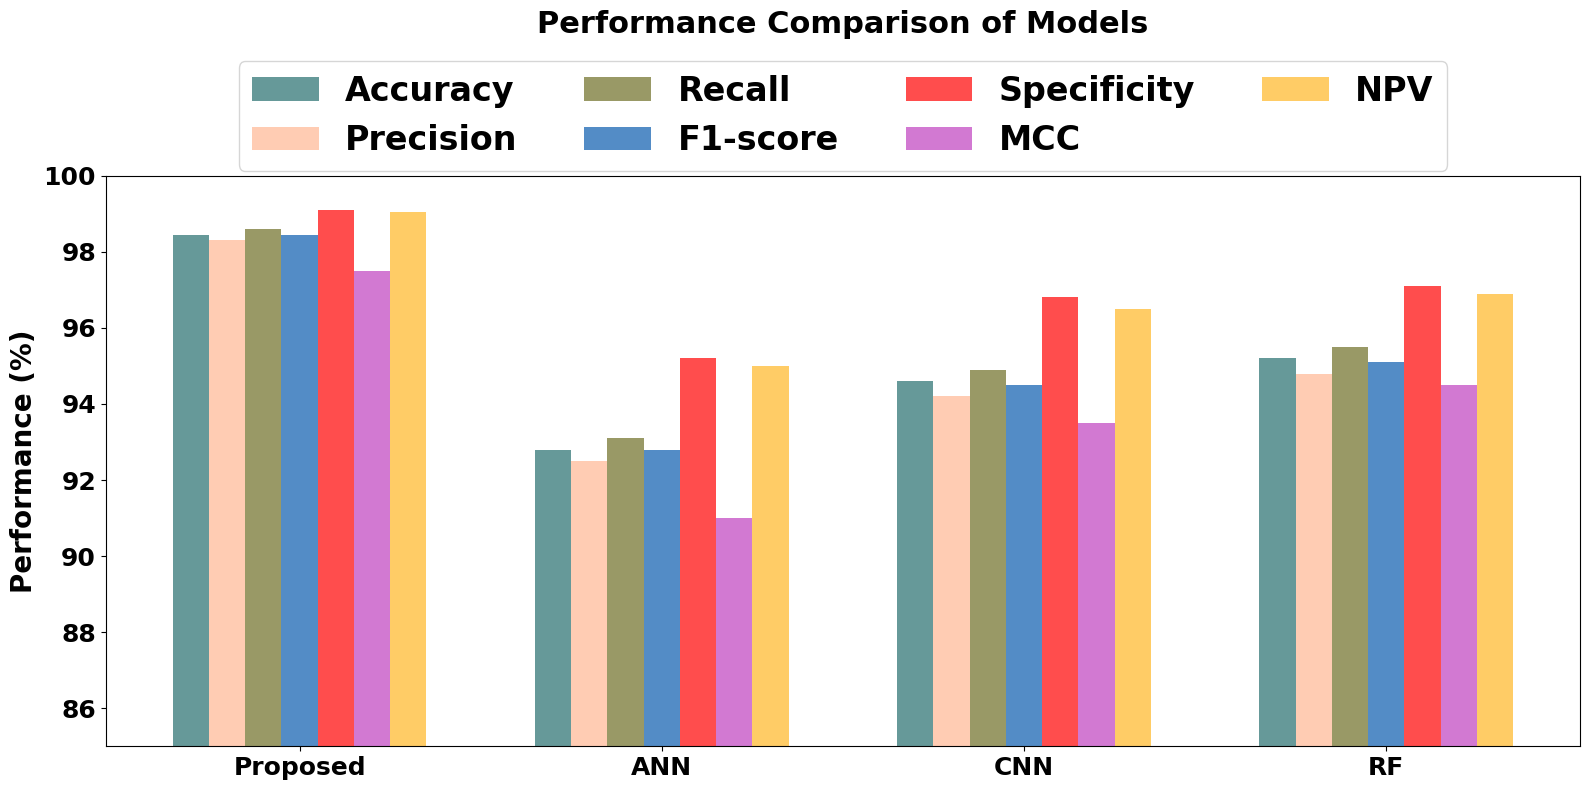

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["Proposed", "ANN", "CNN", "RF"]

# Metrics
accuracy = [98.45, 92.8, 94.6, 95.2]
precision = [98.3, 92.5, 94.2, 94.8]
recall = [98.6, 93.1, 94.9, 95.5]
f1 = [98.45, 92.8, 94.5, 95.1]
specificity = [99.1, 95.2, 96.8, 97.1]
mcc = [97.5, 91.0, 93.5, 94.5]   # converted to %
npv = [99.05, 95.0, 96.5, 96.9]

# color variable
colors = ['#669999', '#ffccb3', '#999966', '#538cc6', '#ff4d4d','#d279d2','#ffcc66']

x = np.arange(len(models))
width = 0.1

plt.figure(figsize=(16,8))

plt.bar(x - 3*width, accuracy, width, label='Accuracy', color=colors[0])
plt.bar(x - 2*width, precision, width, label='Precision', color=colors[1])
plt.bar(x - width, recall, width, label='Recall', color=colors[2])
plt.bar(x, f1, width, label='F1-score', color=colors[3])
plt.bar(x + width, specificity, width, label='Specificity', color=colors[4])
plt.bar(x + 2*width, mcc, width, label='MCC', color=colors[5])
plt.bar(x + 3*width, npv, width, label='NPV', color=colors[6])

plt.xticks(x, models, fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')

plt.ylabel("Performance (%)", fontsize=20, fontweight='bold')
plt.title("Performance Comparison of Models\n\n\n\n", fontsize=22, fontweight='bold')

plt.ylim(85,100)

plt.legend(loc='upper center', bbox_to_anchor=(0.5,1.23),
           ncol=4, prop={'weight':'bold','size':24})

plt.tight_layout()
plt.show()

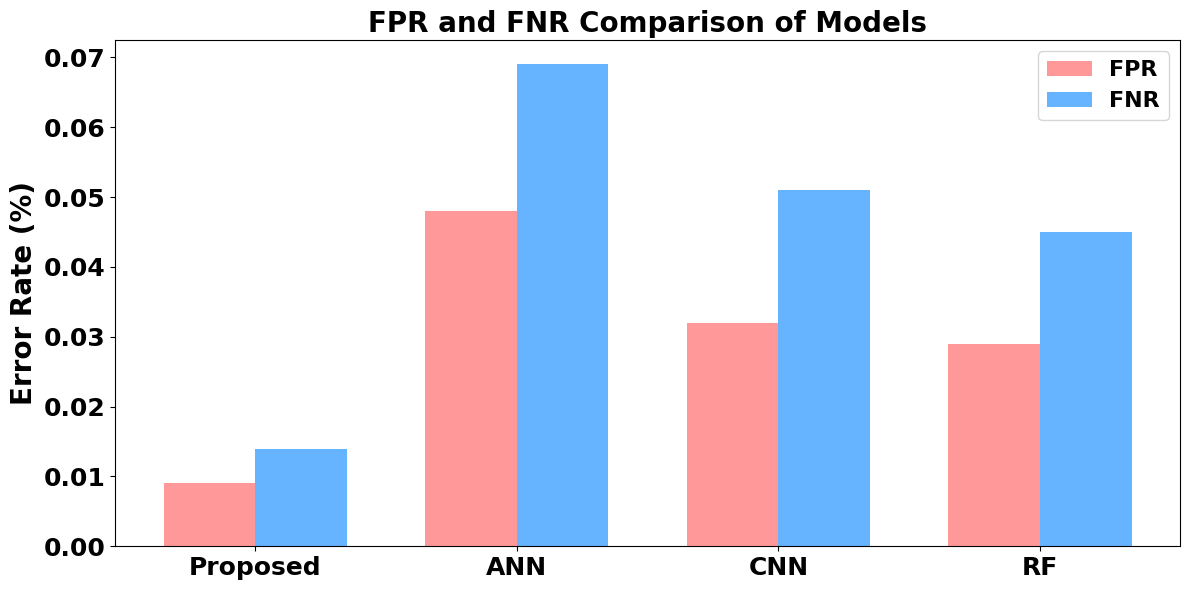

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Proposed", "ANN", "CNN", "RF"]

fpr = [0.009, 0.048, 0.032, 0.029]
fnr = [0.014, 0.069, 0.051, 0.045]


x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(12,6))

plt.bar(x - width/2, fpr, width, label='FPR', color='#ff9999')
plt.bar(x + width/2, fnr, width, label='FNR', color='#66b3ff')

plt.xticks(x, models, fontsize=18, fontweight='bold')
plt.yticks(fontsize=18, fontweight='bold')

plt.ylabel("Error Rate (%)", fontsize=20, fontweight='bold')
plt.title("FPR and FNR Comparison of Models", fontsize=20, fontweight='bold')

plt.legend(prop={'weight':'bold','size':16})
# plt.ylim(0,10)

plt.tight_layout()
plt.show()